### 1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма). В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

data = pd.read_csv('gbm-data.csv')
X = data.iloc[:,1:].values
y = data.iloc[:,0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

### 2. Обучите GradientBoostingClassifier с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:
• Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.

• Преобразуйте полученное предсказание по формуле 1/(1+e^(-y_pred)), где y_pred — предсказанное значение.

• Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

      Iter       Train Loss   Remaining Time 
         1           1.0190            9.19s
         2           0.9192            9.53s
         3           0.8272           10.27s
         4           0.7834           10.60s
         5           0.7109           10.82s
         6           0.6368           10.85s
         7           0.5797           10.88s
         8           0.5610           10.88s
         9           0.5185           10.86s
        10           0.4984           10.89s
        20           0.1999           10.52s
        30           0.1313           10.38s
        40           0.0790           10.08s
        50           0.0511            9.58s
        60           0.0352            9.05s
        70           0.0245            8.53s
        80           0.0162            8.06s
        90           0.0114            7.60s
       100           0.0077            7.11s
       200           0.0002            2.44s


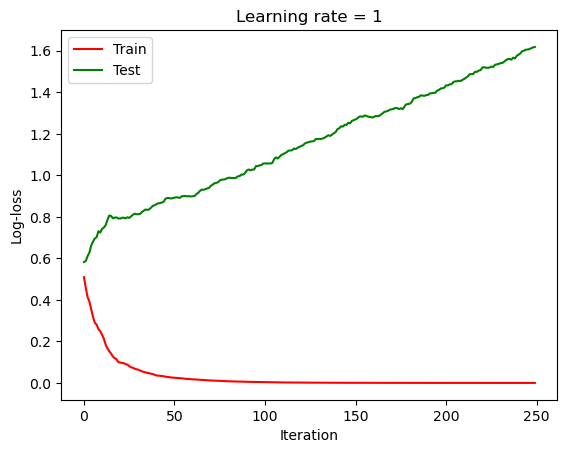

      Iter       Train Loss   Remaining Time 
         1           1.1255            9.41s
         2           1.0035            8.54s
         3           0.9386            8.08s
         4           0.8844            7.93s
         5           0.8381            7.80s
         6           0.7995            7.69s
         7           0.7559            8.05s
         8           0.7205            8.42s
         9           0.6958            8.96s
        10           0.6725            9.18s
        20           0.4672            9.15s
        30           0.3179            9.24s
        40           0.2274            9.31s
        50           0.1774            9.08s
        60           0.1394            8.83s
        70           0.1050            8.54s
        80           0.0805            8.16s
        90           0.0650            7.87s
       100           0.0511            7.39s
       200           0.0058            2.44s


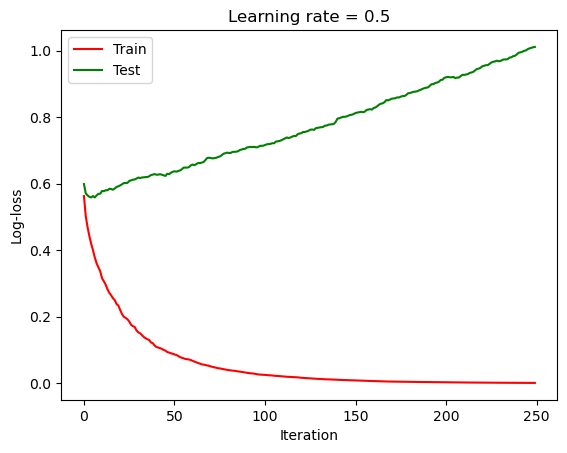

      Iter       Train Loss   Remaining Time 
         1           1.2095           13.34s
         2           1.1006           12.60s
         3           1.0240           12.10s
         4           0.9729           11.81s
         5           0.9387           11.73s
         6           0.8948           11.66s
         7           0.8621           11.55s
         8           0.8360           11.50s
         9           0.8171           11.46s
        10           0.7883           11.51s
        20           0.6164           10.86s
        30           0.4933           10.67s
        40           0.4248           10.20s
        50           0.3345            9.78s
        60           0.2760            9.44s
        70           0.2263            9.10s
        80           0.1971            8.71s
        90           0.1693            8.26s
       100           0.1388            7.74s
       200           0.0294            2.55s


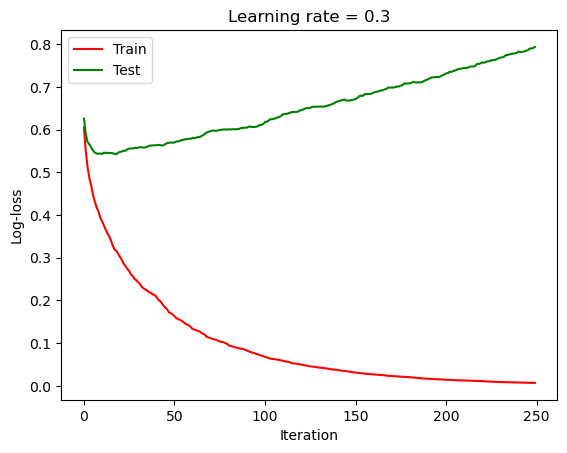

      Iter       Train Loss   Remaining Time 
         1           1.2613           14.55s
         2           1.1715           14.41s
         3           1.1009           14.10s
         4           1.0529           13.95s
         5           1.0130           13.74s
         6           0.9740           13.26s
         7           0.9475           13.28s
         8           0.9197           13.26s
         9           0.8979           13.43s
        10           0.8730           13.35s
        20           0.7207           12.54s
        30           0.6055           11.59s
        40           0.5244           10.79s
        50           0.4501           10.10s
        60           0.3908            9.80s
        70           0.3372            9.26s
        80           0.3009            8.70s
        90           0.2603            8.24s
       100           0.2327            7.74s
       200           0.0835            2.67s


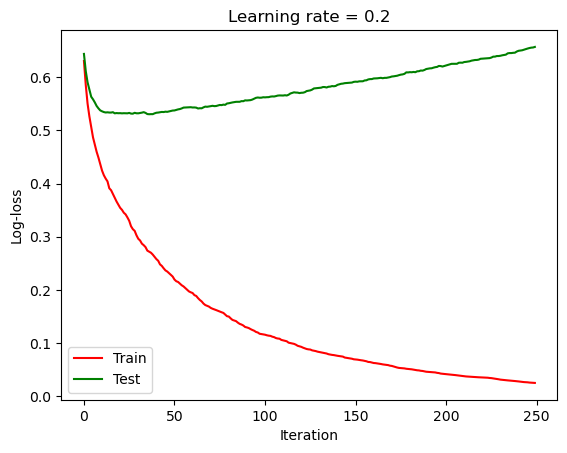

      Iter       Train Loss   Remaining Time 
         1           1.3199           13.14s
         2           1.2645           12.24s
         3           1.2170           11.88s
         4           1.1775           11.68s
         5           1.1404           11.62s
         6           1.1106           11.58s
         7           1.0844           11.54s
         8           1.0617           11.40s
         9           1.0411           11.34s
        10           1.0223           11.39s
        20           0.8864           10.82s
        30           0.7844           10.33s
        40           0.7176           10.02s
        50           0.6590            9.49s
        60           0.6120            9.01s
        70           0.5599            8.54s
        80           0.5242            8.05s
        90           0.4829            7.57s
       100           0.4473            7.08s
       200           0.2379            2.33s


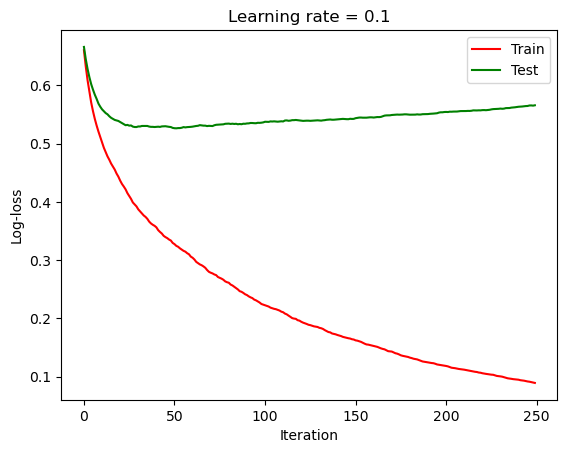

In [2]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
for l_r in learning_rates:
    clf = GradientBoostingClassifier(n_estimators=250, verbose=True, random_state=241, learning_rate=l_r)
    clf.fit(X_train, y_train)

    train_pred = clf.staged_decision_function(X_train)
    test_pred = clf.staged_decision_function(X_test)

    train_loss = []
    test_loss = []

    for y_pred_train, y_pred_test in zip(train_pred, test_pred):
        pred_train = 1.0 / (1.0 + np.exp(-y_pred_train))
        pred_test = 1.0 / (1.0 + np.exp(-y_pred_test))

        train_loss.append(log_loss(y_train, pred_train))
        test_loss.append(log_loss(y_test, pred_test))
    
    min_train_loss = min(train_loss)
    min_test_loss = min(test_loss)
    iter_train = np.argmin(train_loss)
    iter_test = np.argmin(test_loss)

    if l_r == 0.2:
        mtl_4 = min_test_loss
        it_4 = iter_test

    plt.figure()
    plt.plot(train_loss, 'r', label='Train')
    plt.plot(test_loss, 'g', label='Test')
    plt.xlabel('Iteration')
    plt.ylabel('Log-loss')
    plt.title(f'Learning rate = {l_r}')
    plt.legend()
    plt.show()

### 3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)? В ответе укажите одно из слов overfitting либо underfitting.

In [7]:
print('Overfitting')

Overfitting


### 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [8]:
print(str(round(mtl_4, 2)) + ' ' + str(it_4))

0.53 36


### 5. На этих же данных обучите RandomForestClassifier с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [9]:
rfc = RandomForestClassifier(n_estimators=it_4, random_state=241)
rfc.fit(X_train, y_train)

rfc_pred = rfc.predict_proba(X_test)
rfc_log_loss = log_loss(y_test, rfc_pred)
print(round(rfc_log_loss, 2))


0.54


      Iter       Train Loss   Remaining Time 
         1           1.0190           11.78s
         2           0.9192           11.73s
         3           0.8272           11.72s
         4           0.7834           11.76s
         5           0.7109           11.81s
         6           0.6368           11.75s
         7           0.5797           11.72s
         8           0.5610           11.65s
         9           0.5185           11.63s
        10           0.4984           11.61s
        20           0.1999           11.08s
        30           0.1313           10.74s
        40           0.0790           10.57s
        50           0.0511           10.25s
        60           0.0352            9.62s
        70           0.0245            9.03s
        80           0.0162            8.59s
        90           0.0114            8.09s
       100           0.0077            7.57s
       200           0.0002            2.50s


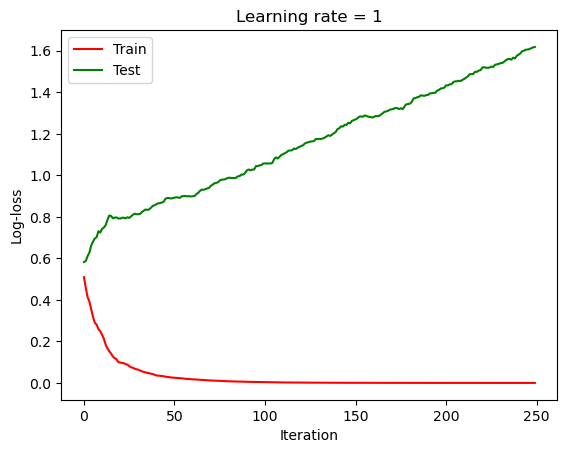

      Iter       Train Loss   Remaining Time 
         1           1.1255           11.71s
         2           1.0035           11.70s
         3           0.9386           12.30s
         4           0.8844           12.11s
         5           0.8381           12.00s
         6           0.7995           11.94s
         7           0.7559           11.82s
         8           0.7205           11.78s
         9           0.6958           11.73s
        10           0.6725           11.70s
        20           0.4672           11.28s
        30           0.3179           10.79s
        40           0.2274           10.30s
        50           0.1774            9.81s
        60           0.1394            9.31s
        70           0.1050            8.84s
        80           0.0805            8.34s
        90           0.0650            7.85s
       100           0.0511            7.37s
       200           0.0058            2.42s


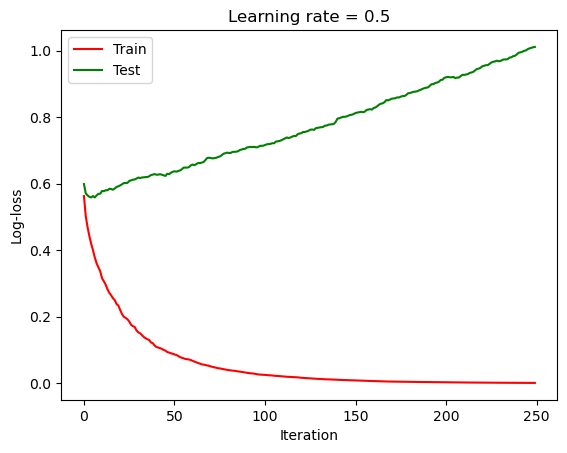

      Iter       Train Loss   Remaining Time 
         1           1.2095           12.10s
         2           1.1006           12.02s
         3           1.0240           12.07s
         4           0.9729           12.40s
         5           0.9387           12.26s
         6           0.8948           12.17s
         7           0.8621           12.14s
         8           0.8360           12.25s
         9           0.8171           12.24s
        10           0.7883           12.26s
        20           0.6164           11.65s
        30           0.4933           11.13s
        40           0.4248           10.62s
        50           0.3345           10.11s
        60           0.2760            9.56s
        70           0.2263            8.99s
        80           0.1971            8.43s
        90           0.1693            7.91s
       100           0.1388            7.40s
       200           0.0294            2.50s


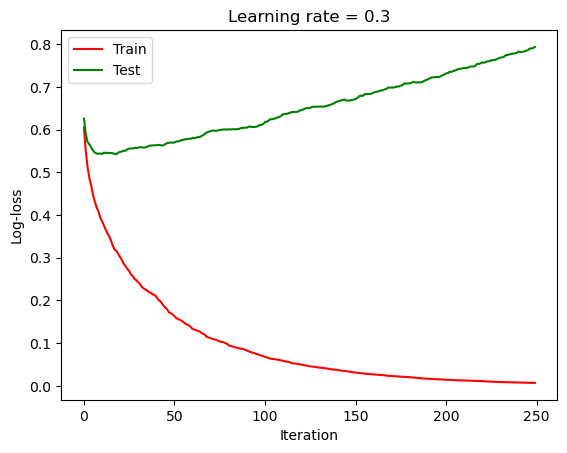

      Iter       Train Loss   Remaining Time 
         1           1.2613           12.40s
         2           1.1715           12.20s
         3           1.1009           11.91s
         4           1.0529           11.73s
         5           1.0130           11.65s
         6           0.9740           11.59s
         7           0.9475           11.53s
         8           0.9197           11.51s
         9           0.8979           11.38s
        10           0.8730           11.36s
        20           0.7207           11.05s
        30           0.6055           10.56s
        40           0.5244           10.06s
        50           0.4501            9.57s
        60           0.3908            9.07s
        70           0.3372            8.59s
        80           0.3009            8.11s
        90           0.2603            7.62s
       100           0.2327            7.16s
       200           0.0835            2.44s


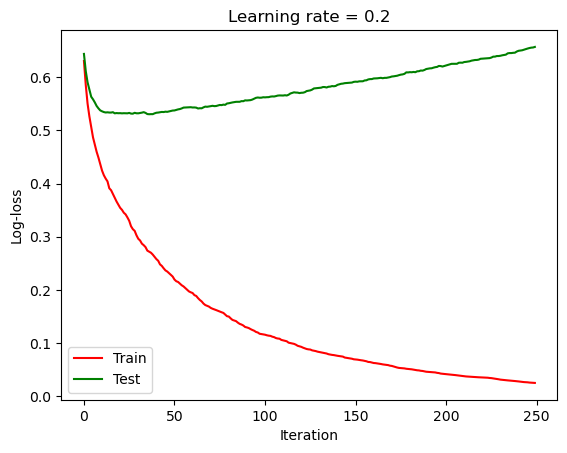

      Iter       Train Loss   Remaining Time 
         1           1.3199           12.51s
         2           1.2645           12.78s
         3           1.2170           12.66s
         4           1.1775           12.43s
         5           1.1404           12.27s
         6           1.1106           12.11s
         7           1.0844           12.03s
         8           1.0617           11.96s
         9           1.0411           11.84s
        10           1.0223           11.74s
        20           0.8864           11.11s
        30           0.7844           10.58s
        40           0.7176           10.09s
        50           0.6590            9.82s
        60           0.6120            9.37s
        70           0.5599            8.91s
        80           0.5242            8.44s
        90           0.4829            7.98s
       100           0.4473            7.52s
       200           0.2379            2.61s


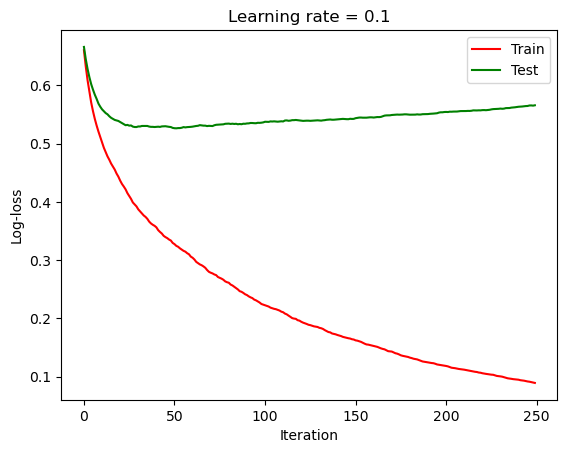

In [10]:
#Общий код для задания
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

data = pd.read_csv('gbm-data.csv')
X = data.iloc[:,1:].values
y = data.iloc[:,0].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size  = 0.8,random_state = 241)

learning_rates = [1,0.5,0.3,0.2,0.1]
for l_r in learning_rates: 
    clf = GradientBoostingClassifier(n_estimators = 250,verbose = True, random_state = 241,learning_rate = l_r)
    clf.fit(X_train,y_train)

    train_pred = clf.staged_decision_function(X_train)
    test_pred = clf.staged_decision_function(X_test)

    train_loss = []
    test_loss = []
    
    for y_pred_train, y_pred_test in zip(train_pred, test_pred):
        pred_train = 1.0 / (1.0 + np.exp(-y_pred_train))
        pred_test = 1.0 / (1.0 + np.exp(-y_pred_test))
        
        train_loss.append(log_loss(y_train, pred_train))
        test_loss.append(log_loss(y_test, pred_test))
    min_train_loss = min(train_loss)
    min_test_loss = min(test_loss)
    iter_train = np.argmin(train_loss)
    iter_test = np.argmin(test_loss)

    if l_r == 0.2:
        mtl_4 = min_test_loss
        it_4 = iter_test

    plt.figure()
    plt.plot(train_loss, 'r', label='Train')
    plt.plot(test_loss, 'g', label='Test')
    plt.xlabel('Iteration')
    plt.ylabel('Log-loss')
    plt.title(f'Learning rate = {l_r}')
    plt.legend()
    plt.show()

with open('3.txt','w') as file:
    file.write('Overfitting')
with open('4.txt','w') as file:
    file.write(str(round(mtl_4,2)) + ' ' + str(it_4))

rfc = RandomForestClassifier(n_estimators = it_4,random_state = 241)
rfc.fit(X_train,y_train)

rfc_pred = rfc.predict_proba(X_test)
rfc_log_loss = log_loss(y_test,rfc_pred)
with open('5.txt','w') as file:
    file.write(str(round(rfc_log_loss,2)))